Copyright (c) Microsoft Corporation. All rights reserved.

Licensed under the MIT License.

# How to Identify Urban Growth Hotspots using Microsoft TEMPO

We'll show you how to move beyond summary statistics and begin identifying patterns of urban growth.

<div style="text-align: center;">
  <img src="https://cdn.sanity.io/images/hvd5n54p/blog/e3a7d1d59c054c8fed735f65425b5bfaf1d218e7-1195x992.jpg?w=2048&q=75&fit=clip&auto=format" width="600">
  <br>
  <em>Building density evolution in Zinder, Niger (2018–2023)</em>
</p>

Welcome to this tutorial, where we'll show you how to interact with the new **Microsoft TEMPO** dataset and identify urban growth hotspots programmatically. TEMPO represents the first global, temporally resolved dataset of building density and height derived from high-resolution satellite imagery.

Understanding how cities change over time is essential for tracking human expansion, informal settlement expansion, and post-disaster recovery, all of which are critical to sustainable development. Unlike datasets that capture only a single moment or cover limited geographies, TEMPO provides consistent, quarterly insights into how the built environment envolves across the globe.

**In this post, we will show you how to load, explore, and prepare the TEMPO data, build a simple building volume proxy, as well as implement a first-pass spatiotemporal clustering exercise to understand urban growth. We'll focus on answering the question: Where is a city growing the most over time?**

We'll cover:
* Open and visualize a TEMPO tile for one location
* Summarize temporal change between two quarters
* Highlight spatial **growth hotspots** where volume increased the most

This tutorial is meant to be beginner-friendly and uses standard Python tools like `numpy`, `pandas`, `rasterio`, and `maptlotlib`. Let's get started!

In [1]:
%load_ext watermark
%watermark -v

Python implementation: CPython
Python version       : 3.8.20
IPython version      : 8.12.3



In [2]:
%watermark -i

## 1. Explore the Data

### Metadata

Before jumping into an analysis, it's important to explore what's inside the dataset. Each TEMPO Cloud Optimized GeoTIFF (COG) contains two continuous bands, which representbuilding density and height, but their value ranges and data coverage can vary between quarters.

The TEMPO dataset is hosted publicly at: `https://opendata.aiforgood.ai/building-density/locations/`

We'll begin by creating a metadata table based on a single known location in the dataset. According to the [TEMPO Github repository](https://github.com/ai-for-good-lab/buildings/tree/dev), high resolution quarterly building density and height COGs are available for five select locations, where `{location}` is one of: `bamako`, `guangdong_province`, `guatemala_department`, `lusaka_district`, `nakuru` and `{quarter}` is one of: `2020q2` through `2025q2`.

Let's create a metadata table and look at what we have.

In [3]:
from typing import List

import pandas as pd

pd.set_option("max_colwidth", 130)

In [4]:
LOCATIONS = [
    "bamako",
    "guangdong_province",
    "guatemala_department",
    "lusaka_district",
    "nakuru",
]

QUARTERS = [
    "2020q2",
    "2020q3",
    "2020q4",
    "2021q1",
    "2021q2",
    "2021q3",
    "2021q4",
    "2022q1",
    "2022q2",
    "2022q3",
    "2022q4",
    "2023q1",
    "2023q2",
    "2023q3",
    "2023q4",
    "2024q1",
    "2024q2",
    "2024q3",
    "2024q4",
    "2025q1",
    "2025q2",
]

BASE_URL = "https://opendata.aiforgood.ai/building-density/locations/{location}/{quarter}_cog.tif"

In [5]:
def create_metadata_table(locations: List[str], quarters: List[str], base_url: str):
    """Construct a metadata table based on available locations and quarters.

    Inputs:
        locations (list[str]): List of locations.
        quarters (list[str]): List of quarters.
        base_url (str): URL expecting dynamic location and quarter values.

    Outputs:
        metadata (pd.DataFrame): Pandas dataframe containing location and time metadata.
    """
    records = []
    for location in locations:
        for quarter in quarters:
            url = base_url.format(location=location, quarter=quarter)
            records.append(
                {
                    "image_id": f"{location}_{quarter}",
                    "location": location,
                    "timestamp": quarter,
                    "year": quarter[:4],
                    "quarter": quarter[4:],
                    "url": url,
                }
            )
    return pd.DataFrame(records).set_index("image_id")

In [6]:
# Construct a synthetic metadata table
metadata = create_metadata_table(
    locations=LOCATIONS, quarters=QUARTERS, base_url=BASE_URL
)

In [7]:
metadata.shape

(105, 5)

In [8]:
metadata.head(3)

,location,timestamp,year,quarter,url
image_id,,,,,
bamako_2020q2,bamako,2020q2,2020,q2,https://opendata.aiforgood.ai/building-density/locations/bamako/2020q2_cog.tif
bamako_2020q3,bamako,2020q3,2020,q3,https://opendata.aiforgood.ai/building-density/locations/bamako/2020q3_cog.tif
bamako_2020q4,bamako,2020q4,2020,q4,https://opendata.aiforgood.ai/building-density/locations/bamako/2020q4_cog.tif


In [9]:
metadata.tail(3)

,location,timestamp,year,quarter,url
image_id,,,,,
nakuru_2024q4,nakuru,2024q4,2024,q4,https://opendata.aiforgood.ai/building-density/locations/nakuru/2024q4_cog.tif
nakuru_2025q1,nakuru,2025q1,2025,q1,https://opendata.aiforgood.ai/building-density/locations/nakuru/2025q1_cog.tif
nakuru_2025q2,nakuru,2025q2,2025,q2,https://opendata.aiforgood.ai/building-density/locations/nakuru/2025q2_cog.tif


In [10]:
metadata.groupby("location")["timestamp"].nunique()

location
bamako                  21
guangdong_province      21
guatemala_department    21
lusaka_district         21
nakuru                  21
Name: timestamp, dtype: int64

The TEMPO dataset contains 5 temporal locations over 21 timestamps, resulting in 105 distinct COGs. We've generated a unique `image_id` for each COG, composed of `{location}_{timestamp}`. This table will act as our lightweight metadata which we'll use throughout this notebook to look up file URLs.

### Inspect a Single Tile

Next, let's look at one location and one quarter to better understand what the data looks like.

In [11]:
from pprint import pprint

import matplotlib.pyplot as plt
import rasterio

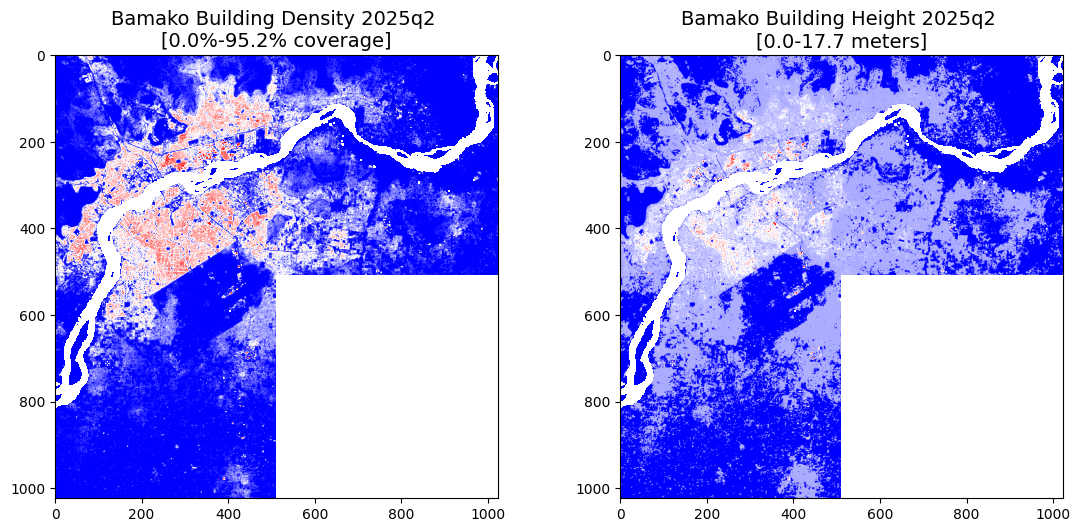

In [12]:
f, ax = plt.subplots(1, 2, figsize=(12, 12))

with rasterio.open(metadata.loc["bamako_2025q2"]["url"]) as src:
    img = src.read(masked=True)
    profile = src.profile

    # Visualize density and height; clip the max to heighten color saturation
    density_min = img[0].min()
    density_max = img[0].max()
    ax[0].imshow(img[0], cmap="bwr", vmin=density_min, vmax=density_max * 0.6)
    ax[0].set_title(
        f"Bamako Building Density 2025q2 \n[{density_min * 100:.1f}%-{density_max * 100:.1f}% coverage]",
        fontsize=14,
    )

    height_min = img[1].min()
    height_max = img[1].max()
    ax[1].imshow(img[1], cmap="bwr", vmin=height_min, vmax=height_max * 0.4)

    # Multiply by 100 to get height in meters
    ax[1].set_title(
        f"Bamako Building Height 2025q2 \n[{height_min * 100:.1f}-{height_max * 100:.1f} meters]",
        fontsize=14,
    )

    plt.tight_layout(pad=5)
    plt.show()

In [13]:
img.shape

(2, 1024, 1024)

In [14]:
pprint(profile)

{'blockxsize': 512,
 'blockysize': 512,
 'compress': 'lzw',
 'count': 2,
 'crs': CRS.from_epsg(3857),
 'driver': 'GTiff',
 'dtype': 'float32',
 'height': 1024,
 'interleave': 'pixel',
 'nodata': -1.0,
 'tiled': True,
 'transform': Affine(38.21851414258799, 0.0, -900122.4450862354,
       0.0, -38.21851414258799, 1428455.1845933737),
 'width': 1024}


Using just a few lines of code we can begin to understand the contents of a single image file. Each file contains two bands: building density and building height. Band 1 contains building density values ranging from 0-1, representing the fraction of each pixel covered by buildings. In 2025q2, Bamako has pixel values ranging from 0 (0% coverage) to 0.95 (95% coverage). Band 2 contains building height values ranging from 0-1, representing normalized building height . To convert these to building height in meters, we simply multiply by 100. Bamako has pixel values ranging from 0 to 17.7 meters, or about 6 stories high.

Each image is stored as a 1024 x 1024 pixel GeoTIFF, comprised of four 512 x 512 internal tiles, which speeds up reads. Similarly to Bing Maps, these files utilize the Web Mercator projection (`EPSG:3857`). Based on the image `transform`, each pixel represents ~38.2 meters on the ground. Pixels contain continuous, floating-point values, and missing or invalid pixels are marked with -1. These should be ignored when calculating any image summary statistics.

In [15]:
from rasterio.plot import show_hist

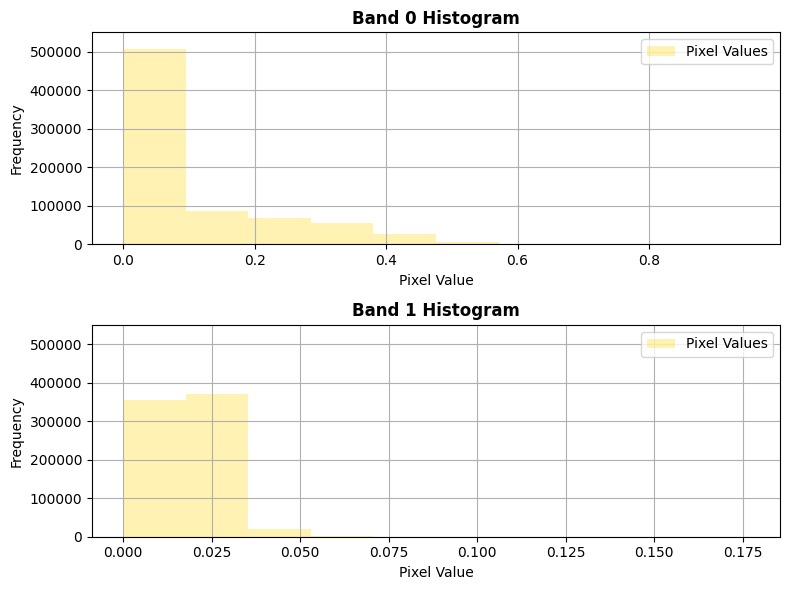

In [16]:
# Plot a histogram each each image band's values
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
n_bands = img.shape[0]

# Iterate through each band
for i in range(n_bands):
    band_data = img[i]
    show_hist(
        band_data,
        bins=10,
        alpha=0.3,
        title=f"Band {i} Histogram",
        ax=axes[i],
        label=["Pixel Values"],
    )
    axes[i].set_ylim(0, 550000)  # Set a consistent y-axis to draw comparisons
    axes[i].set_xlabel("Pixel Value")

plt.tight_layout()

Looking at the histogram of each band's values provides preliminary information about the scene. Band 0 (density) indicates that most pixels contain no buildings, or have minimal building coverage (<20%). Pixels with buildings tend to have 20-60% coverage. Band 1 (height) shows us that building heights tend to fall between 0-5 meters, with few pixels containing taller buildings. Given that 1 story is approximately 3 meters, this indicates that most buildings in Bamako are 2 stories or less.

## 2. Change Over Time

To begin identifying areas of high growth, let's expand our metadata table to capture information about change over time for **Bamako, Mali**. Bamako is the capital and largest city of Mali, with a population well over 4 million people. Located on the banks of the Niger River, the city plays a key role in river transport and regional trade. Bamako has experienced one of the fastest urban growth rates in Africa, and is host to ~70% of Mali's industrial activity.

### Summary Statistics

In [17]:
import numpy as np

In [18]:
bamako_metadata = metadata[metadata.location == "bamako"].copy()
bamako_metadata.head(3)

,location,timestamp,year,quarter,url
image_id,,,,,
bamako_2020q2,bamako,2020q2,2020,q2,https://opendata.aiforgood.ai/building-density/locations/bamako/2020q2_cog.tif
bamako_2020q3,bamako,2020q3,2020,q3,https://opendata.aiforgood.ai/building-density/locations/bamako/2020q3_cog.tif
bamako_2020q4,bamako,2020q4,2020,q4,https://opendata.aiforgood.ai/building-density/locations/bamako/2020q4_cog.tif


In [19]:
def compute_summary_stats(url: str):
    """Compute basic summary statistics for each URL.

    Inputs:
        url (str): URL to read, representing a GeoTIFF.

    Outputs:
        dataframe (pd.DataFrame): DataFrame containing summary statistics
            for all valid pixels, and for built pixels.
    """
    with rasterio.open(url) as src:
        img = src.read(masked=True)
        transform = src.transform
        pixel_area = abs(transform.a) * abs(transform.e)  # Pixel area
        density, height = img[0], img[1]

        # Calculate stats over valid and built pixels
        valid = np.isfinite(density)
        built = valid & (density > 0)
        height_m = height * 100

        rows = []
        row = {
            "built_fraction": built.sum() / valid.sum(),
            "mean_density_valid": np.nanmean(density[valid]),
            "std_density_valid": np.nanstd(density[valid]),
            "mean_density_built": np.nanmean(density[built]),
            "std_density_built": np.nanstd(density[built]),
            "mean_height_valid": np.nanmean(height_m[valid]),
            "std_height_valid": np.nanstd(height_m[valid]),
            "mean_height_built": np.nanmean(height_m[built]),
            "std_height_built": np.nanstd(height_m[built]),
            "mean_volume_proxy_built": np.nanmean((density * height_m)[built]),
            "mean_volume_proxy_valid": np.nanmean((density * height_m)[valid]),
            "total_volume_proxy": np.nansum((density * height_m) * pixel_area),
        }
    return row

In [20]:
# Calculate summary statistics and combine with existing metdata
bamako_summary_stats = pd.DataFrame(
    [compute_summary_stats(url) for url in bamako_metadata.url]
)
bamako_metadata = pd.concat(
    [
        bamako_metadata.reset_index(drop=False),
        bamako_summary_stats.reset_index(drop=True),
    ],
    axis=1,
).set_index("image_id")

In [21]:
bamako_metadata.head(3)

,location,timestamp,year,quarter,url,built_fraction,mean_density_valid,std_density_valid,mean_density_built,std_density_built,mean_height_valid,std_height_valid,mean_height_built,std_height_built,mean_volume_proxy_built,mean_volume_proxy_valid,total_volume_proxy
image_id,,,,,,,,,,,,,,,,,
bamako_2020q2,bamako,2020q2,2020,q2,https://opendata.aiforgood.ai/building-density/locations/bamako/2020q2_cog.tif,0.455704,0.074385,0.121542,0.163230,0.133846,1.194509,1.359810,2.621239,0.563776,0.483487,0.220327,240943856.0
bamako_2020q3,bamako,2020q3,2020,q3,https://opendata.aiforgood.ai/building-density/locations/bamako/2020q3_cog.tif,0.461945,0.075436,0.122145,0.163301,0.133972,1.214099,1.368066,2.628230,0.578710,0.486330,0.224658,245680384.0
bamako_2020q4,bamako,2020q4,2020,q4,https://opendata.aiforgood.ai/building-density/locations/bamako/2020q4_cog.tif,0.465263,0.075752,0.121915,0.162815,0.133306,1.218814,1.363286,2.619622,0.570116,0.481700,0.224117,245088992.0


### Data Visualization 

Let's take a look at how the fraction of built pixels in Bamako has changed from 2020q2-2025q2.

In [22]:
def plot_change(metadata: pd.DataFrame, column: str):
    """Given metadata for a series of timestamps and column,
    plot change over time.

    Inputs:
        metadata (pd.DataFrame): DataFrame containing a timestamp column.
        column (str): Variable to plot over time (e.g., "built_fraction").
    """
    plt.figure(figsize=(10, 3))
    plt.plot("timestamp", column, data=metadata, color="lightgray", linewidth=2)
    plt.ylabel(f"{column}")
    plt.xticks(rotation=45)
    plt.title(
        f"{column} over time in {metadata.iloc[0].location.capitalize()} \n(2020q2-2025q2)"
    )

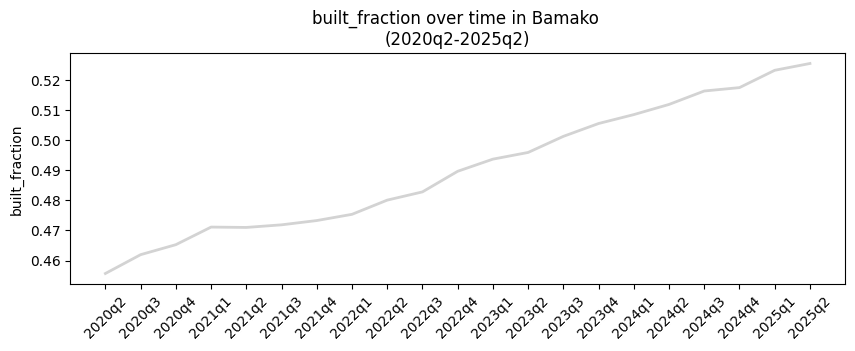

In [23]:
plot_change(bamako_metadata, "built_fraction")

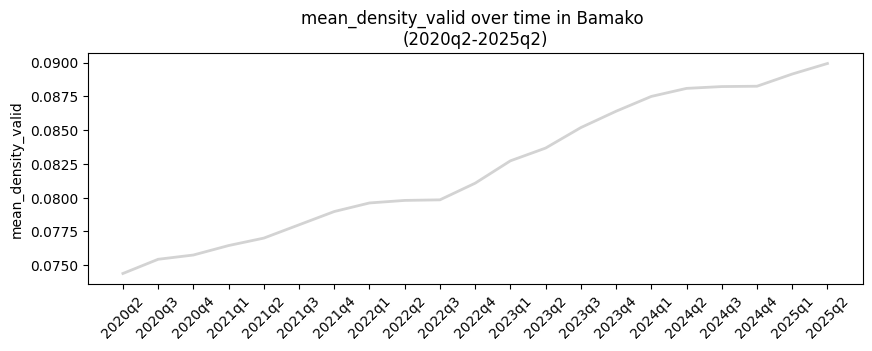

In [24]:
plot_change(bamako_metadata, "mean_density_valid")

The data tell us that between 2020q2 and 2025q2, the average percentage of each pixel that contains buildings steadily increased from 46% to over 52%. In parallel, the average building density of a valid pixel increased from 7.5% to 9%. This is a clear indicator of urban development over a 5-year time period.

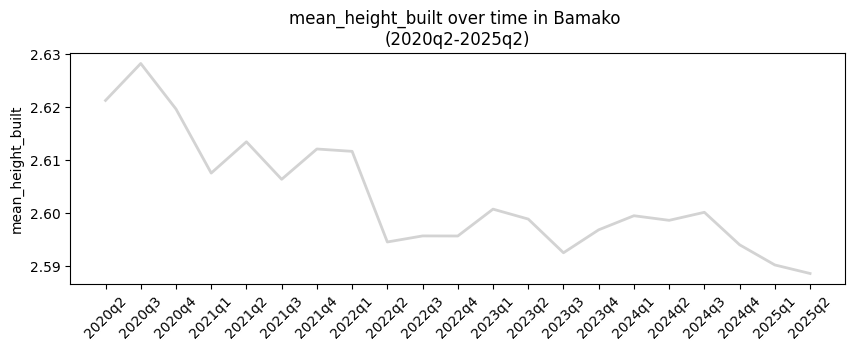

In [25]:
plot_change(bamako_metadata, "mean_height_built")

However, we can see that the average height over built pixels gradually decreased from 2.63 to 2.59 meters. This slight reduction likely indicates new low-height developments, or horizontal growth, while the majority of existing tall structures remain in place.

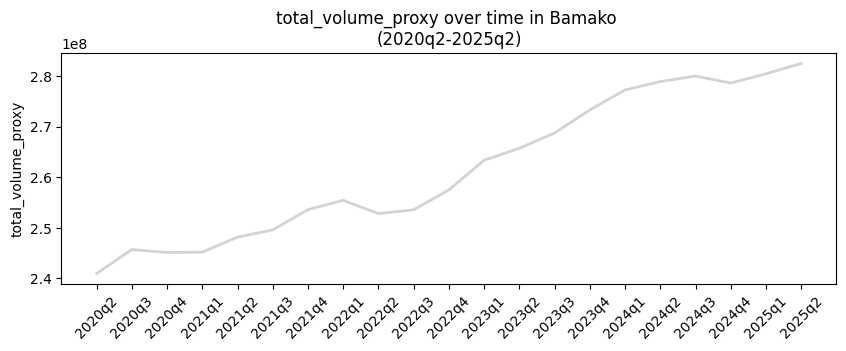

In [26]:
plot_change(bamako_metadata, "total_volume_proxy")

It’s important to note that pixel area, when derived from the image transform in the Web Mercator projection, represents projected area rather than the true ground area. Because Web Mercator distorts scale with latitude, pixel width and height increase as you move away from the equator. However, since this scene covers a relatively small geographic extent, these distortions are negligible for our purposes, and we can still interpret temporal changes in built volume.

The plot above shows that between 2020q2 and 2025q2, the total 3D built-up mass in Bamako increases substantially, from approximately 240 million m³ to 280 million m³. This proxy metric is proportional to the growth of human settlements, though it should not be interpreted as a precise measure of physical building volume.

### Mapping High Growth

Next, let's compute a proxy for pixel-level volume and visually inspect change in building volume over time for this scene.

In [27]:
# Define helper functions to load data, compute volume, and compute change in volume
def load_tempo_file(url: str):
    """Load a single file, and return density, height, and metadata.

    Inputs:
        url (str): URL for a single COG.

    Outputs:
        density (np.array): Numpy array representing building density.
        height (np.array): Numpy array representing building height.
        profile (dict): Dictionary containing image metadata.
    """
    with rasterio.open(url) as src:
        img = src.read(masked=True)
        density, height = img[0], img[1]
        profile = src.profile
    return density, height, profile


def compute_volume_proxy(density: np.array, height: np.array, pixel_area: float):
    """Given density and height, compute a pixel-level proxy for volume in
    cubic meters.

    Inputs:
        density (np.array): Numpy array representing building density.
        height (np.array): Numpy array representing building height.
        pixel_area (float): Approximate area of a single pixel.

    Outputs:
        volume (np.array): Numpy array representing a proxy for building volume.
    """
    height_m = height * 100
    return density * height_m * pixel_area


def compute_change(volume_early: np.array, volume_late: np.array):
    """Compute change in volume between valid pixels across two timestamps.

    Inputs:
        volume_early (np.array): Numpy array for volume from an early timestamp.
        volume_late (np.array): Numpy array for volume from a later timestamp.

    Outputs:
        delta_volume (np.array): Volume delta for valid pixels between timestamps.
    """
    valid = np.isfinite(volume_early) & np.isfinite(volume_late)
    delta_volume = np.full_like(volume_early, np.nan, dtype=np.float32)
    delta_volume[valid] = volume_late[valid] - volume_early[valid]
    return delta_volume

In [28]:
# Load early and later timestamp
url_2020q2 = bamako_metadata.loc["bamako_2020q2"]["url"]
url_2025q2 = bamako_metadata.loc["bamako_2025q2"]["url"]
density_early, height_early, profile_early = load_tempo_file(url_2020q2)
density_late, height_late, profile_late = load_tempo_file(url_2025q2)

# Compute volume proxy for each timestamp at the pixel level
pixel_width = abs(profile_early["transform"].a)
pixel_height = abs(profile_early["transform"].e)
pixel_area = pixel_width * pixel_height

volume_early = compute_volume_proxy(density_early, height_early, pixel_area)
volume_late = compute_volume_proxy(density_late, height_late, pixel_area)

# Compute absolute change for valid pixels
delta_volume = compute_change(volume_early, volume_late)

In [29]:
print(f"Maximum positive change in volume: {delta_volume.max():.2f} m³")
print(f"Maximum negative change in volume: {delta_volume.min():.2f} m³")

Maximum positive change in volume: 14907.45 m³
Maximum negative change in volume: -7247.91 m³


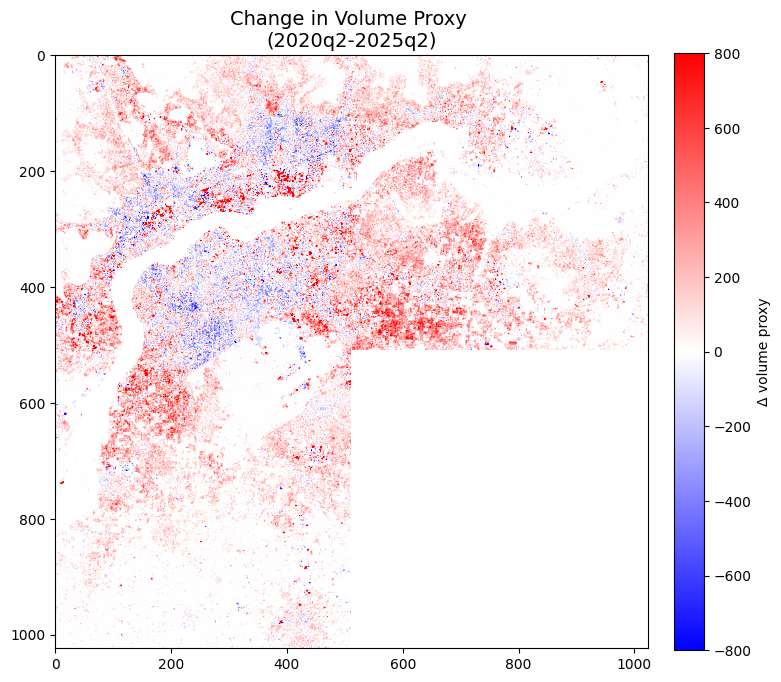

In [30]:
# Visualize density and height; clip the range to heighten color saturation
f, ax = plt.subplots(1, 1, figsize=(9, 9))

img = ax.imshow(delta_volume, cmap="bwr", vmin=-800, vmax=800)
ax.set_title("Change in Volume Proxy \n(2020q2-2025q2)", fontsize=14)
fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04, label="Δ volume proxy")
plt.tight_layout(pad=5)
plt.show()

We can begin to visually parse out areas of higher and lower growth. Locations highlighted in dark blue represent places that have experienced a reduction in building volume over the past 5 years, while locations in red represent areas of development. Between 2020 and 2025, we can see that the city has spread outward, with most new construction occurring in peri-urban areas rather than the city center. Volume reduction in the city center may represent the replacement of informal multi-story structures with lower, permanent buildings, reducing average height. 

## 3. Cluster Analysis

To find growth hotspots, we can keep the positive changes and identify the top 5% of these at **hotspots**. To reduce noise, let's group contiguous pixels into clusters using `scipy.ndimage.label` and summarize them.

### Finding Hotspots

In [31]:
from pathlib import Path

import folium
from PIL import Image
from rasterio.transform import xy
from rasterio.warp import transform
from scipy import ndimage

In [32]:
# Isolate positive changes
positive_delta = np.where(delta_volume > 0, delta_volume, 0)
threshold = np.percentile(positive_delta, 95)

# Mask for top-quartile growth (hotspots)
hotspots = positive_delta >= threshold

# Group hotspots into clusters using a simple 8-connectivity algorithm
labels, num_clusters = ndimage.label(hotspots)
print("Number of hotspot clusters:", num_clusters)

Number of hotspot clusters: 22996


Next, let's visualize a single high growth cluster, to see if we can validate an area of new growth.

In [33]:
# Identify the cluster ID with the most pixels
best_id = (
    np.argmax(np.bincount(labels.flat)[1:]) + 1
)  # Indexing at 1 skips the background
max_area = np.sum(labels == best_id)
print(f"Largest cluster ID: {best_id} contains {max_area} pixels")

Largest cluster ID: 15729 contains 573 pixels


Now that we've identified a cluster to visualize, let's create a bounding box around it.

In [34]:
# Mask for cluster 4925 and crop to its bounding box
rows, cols = np.where(labels == best_id)
rmin, rmax, cmin, cmax = rows.min(), rows.max(), cols.min(), cols.max()
mask_crop = labels[rmin:rmax, cmin:cmax] == best_id

# Get bounds of the crop window in the raster's CRS
x_min, y_max = xy(profile["transform"], rmin, cmin)
x_max, y_min = xy(profile["transform"], rmax, cmax)

# Reproject bounds to WGS84 lat/lon for folium
(lon_min, lon_max), (lat_min, lat_max) = transform(
    "EPSG:3857",
    "EPSG:4326",
    [x_min, x_max],
    [y_min, y_max],
)
west, east = lon_min, lon_max
south, north = lat_min, lat_max

Finally, let's overlay positive growth on an OpenStreetMap basemap.


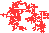

In [35]:
# Create a red overlay from the mask
rgba = (np.expand_dims(mask_crop, axis=-1) * [255, 0, 0, 200]).astype(
    np.uint8
)  # Highlights red channel
overlay_path = Path.cwd() / "pics" / "high_growth_cluster.png"
overlay_path.parent.mkdir(parents=True, exist_ok=True)
Image.fromarray(rgba).save(str(overlay_path))

# Build a folium map
m = folium.Map(
    location=[(south + north) / 2, (west + east) / 2],  # Center lat/lon
    zoom_start=16,
    tiles=None,
)

# Add base layers
folium.TileLayer("Esri.WorldImagery", name="Satellite (Esri)").add_to(m)
folium.TileLayer("OpenStreetMap", name="OpenStreetMap").add_to(m)

folium.raster_layers.ImageOverlay(
    image=str(overlay_path),
    bounds=[[south, west], [north, east]],
    opacity=0.6,
    name="High-growth cluster",
).add_to(m)

folium.LayerControl().add_to(m)

m

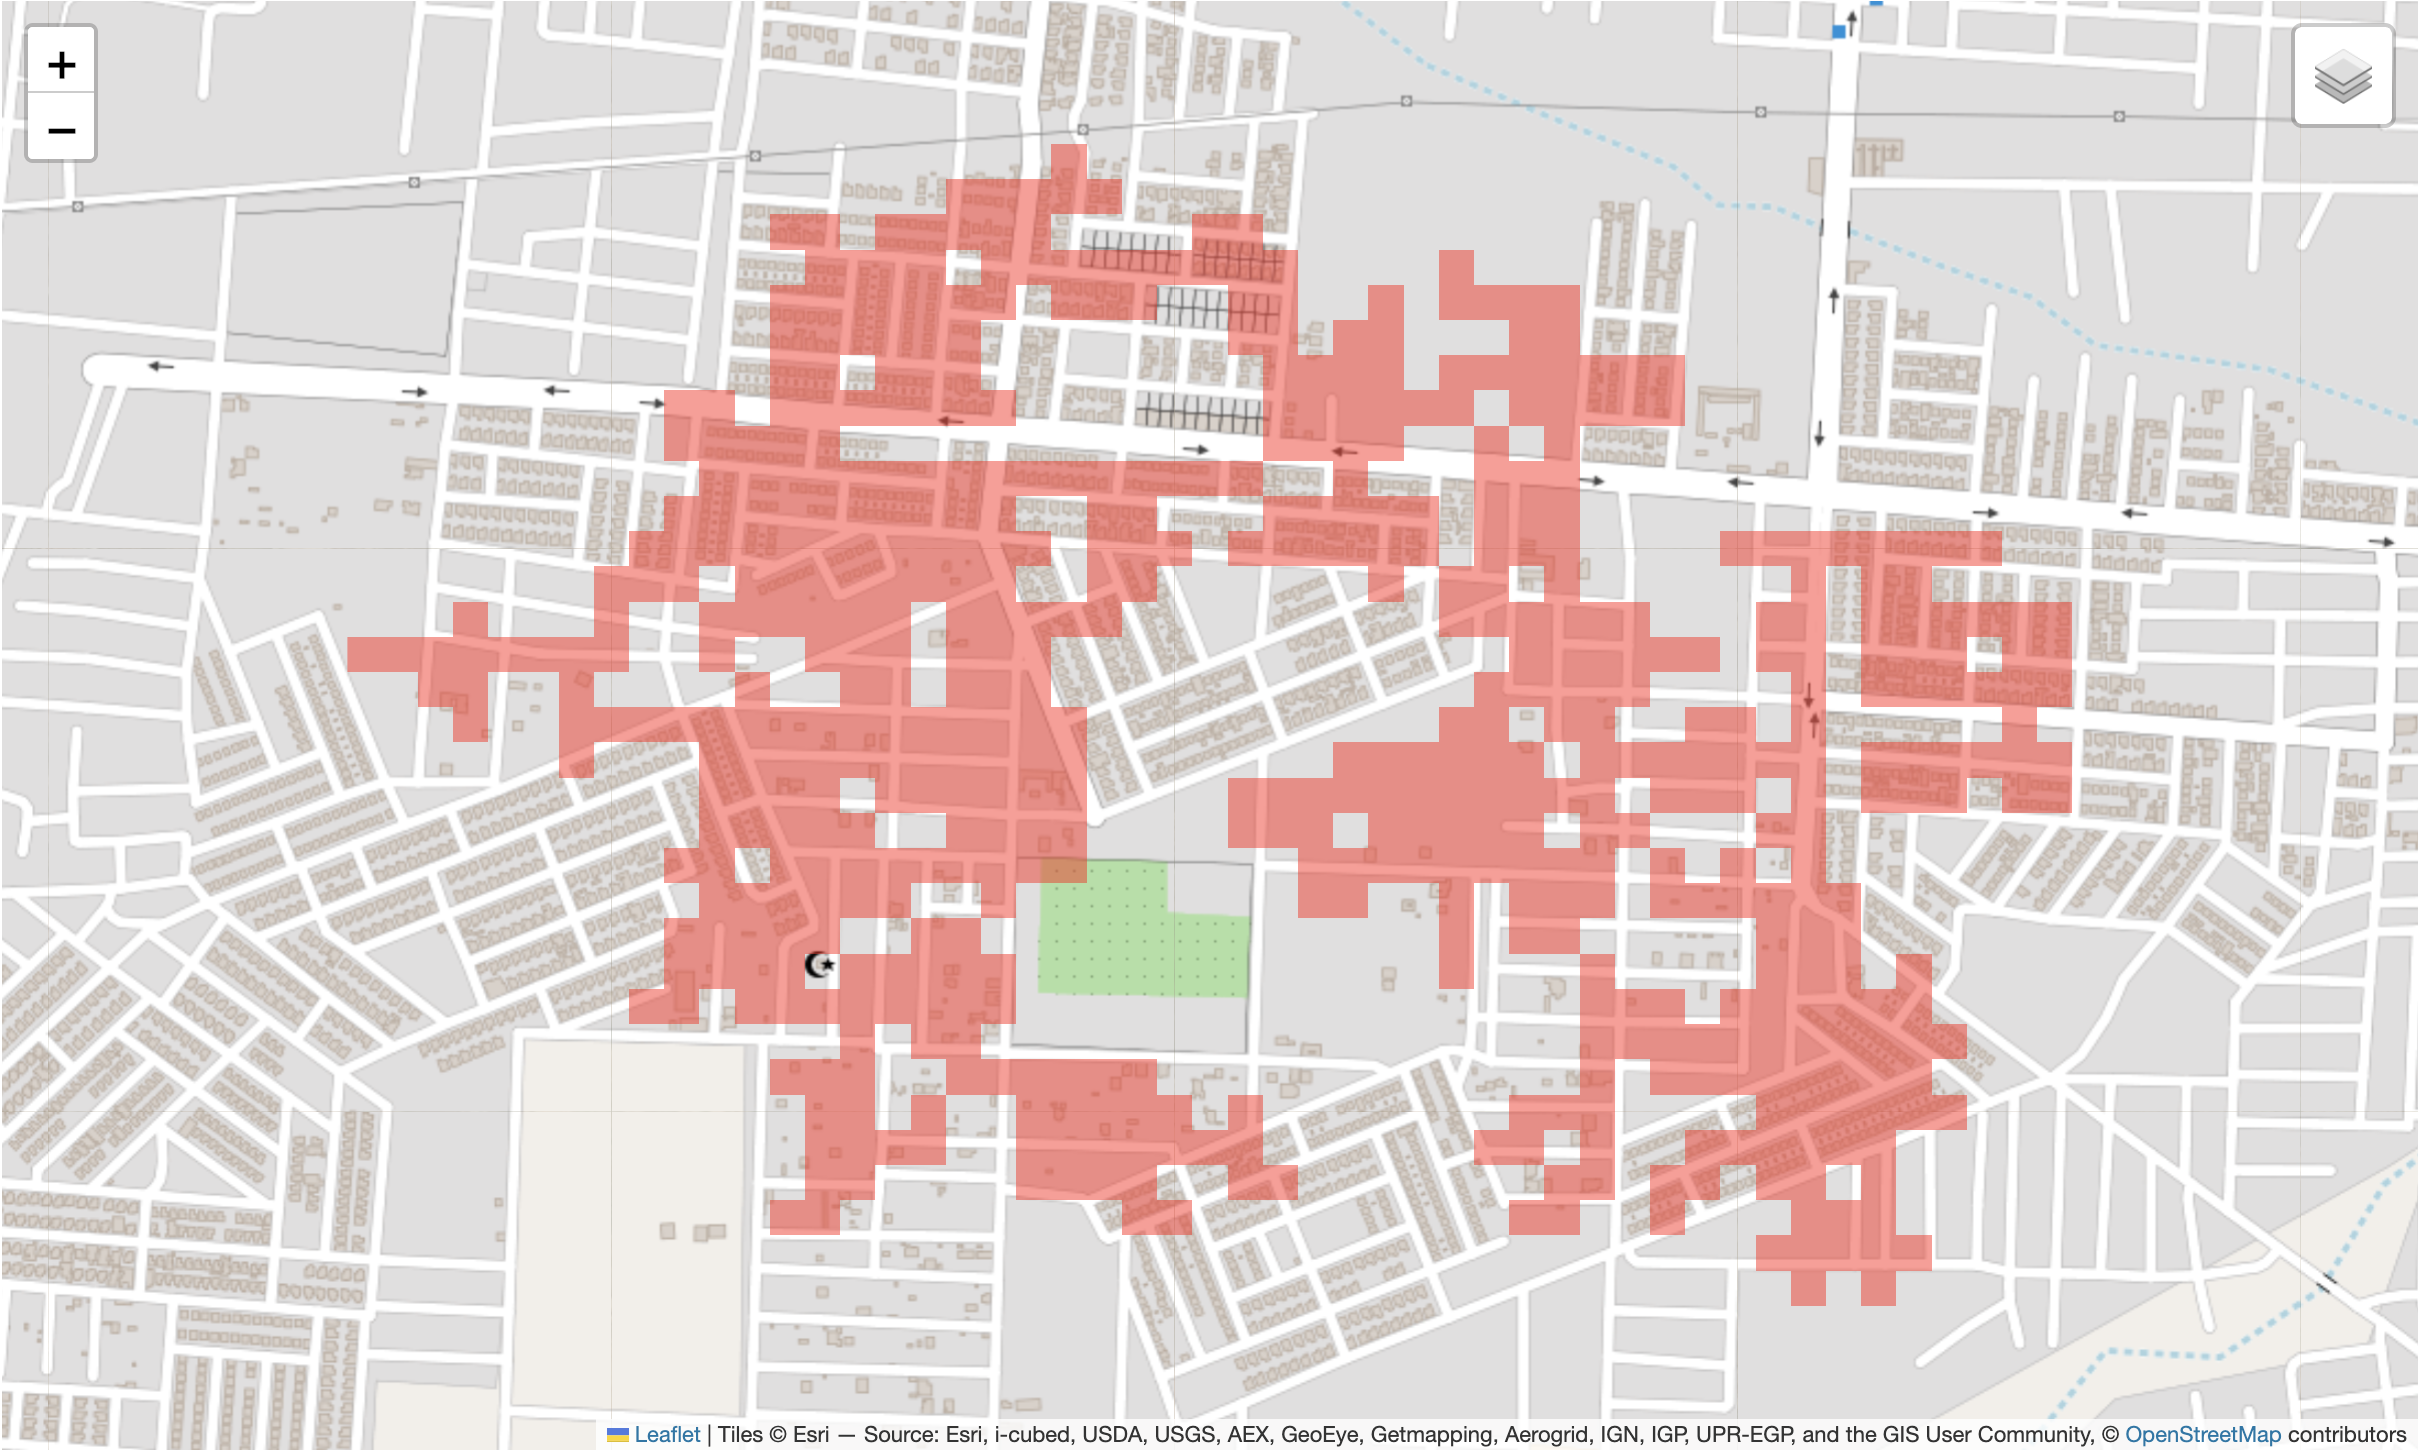

In [36]:
# Note: GitHub’s static viewer doesn’t run JavaScript. Open the notebook locally to see the interactive map.
from IPython.display import Image, display

display(Image(filename="../images/mali-preview.png", width=800))

This map displays a high-growth cluster by volume proxy in the peri-urban area of Dialakorobougou, Mali. Interestingly, we can see that many of the pixels above do not overlap with known buildings on OpenStreetMap (OSM). However, when you toggle to the satellite view (top right corner), there are clearly buildings present in these locations. TEMPO data can be used to find areas of high growth where OSM is outdated.

Bamako’s expansion is increasingly spilling beyond its historic core. A recent Luxembourg Red Cross report describes a major rehabilitation project that was completed in September 2025 in nearby Banconi, Mali. Between 2017 and 2025, 530 houses were rehabilitated to benefit vulnerable familes and improve living conditions. [See source for more information](https://www.croix-rouge.lu/en/blog/banconi-a-neighbourhood-transformed-for-more-sustainable-living-conditions/). This pattern of densification is visible above, reinforcing a broader wave of peri-urban development transforming the edges of the city.

## What Did We Learn?

In this tutorial, we:

- Loaded TEMPO building density and height tiles directly from cloud storage
- Created a simple **volume proxy** at the pixel level using density × height in meters x pixel area
- Compared an early quarter (2020q2) to a later quarter (2025q2) to compute change
- Highlighted **growth hotspots** where building volume increased the most
- Grouped contiguous hotspots into clusters and visualized the largest hotspot
  
From here, you could:
- Repeat the analysis for multiple locations and compare their hotspot patterns
- Use additional data (roads, admin boundaries, population) to interpret clusters
- Track clusters across multiple time steps to see how growth moves over time

TEMPO data lets us move beyond measuring how much urban growth has occurred to understanding where and how it’s unfolding, revealing the spatial patterns and intensity of change across time. **We look forward to seeing what you build with this data!**